## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# random.choises(campione, N)

def lancio_moneta(N):
    lista = np.array([np.random.randint(0,2) for i in range(N)])
    return round(lista.mean()*100, 2)

print(lancio_moneta(15))

80.0


In [ ]:
#100 campioni che vanno da 10 a 20000 lanci 
numero_lanci = np.linspace(10, 20000, 100)
#percentuale di teste per campione
risultati = [lancio_moneta(int(x)) for x in numero_lanci]

[np.float64(60.0), np.float64(46.45), np.float64(51.09), np.float64(53.66), np.float64(50.18), np.float64(49.17), np.float64(50.94), np.float64(49.33), np.float64(50.95), np.float64(49.97), np.float64(49.83), np.float64(49.84), np.float64(50.23), np.float64(49.66), np.float64(50.0), np.float64(50.36), np.float64(49.78), np.float64(49.16), np.float64(50.8), np.float64(50.1), np.float64(49.7), np.float64(49.88), np.float64(49.1), np.float64(48.43), np.float64(49.61), np.float64(50.96), np.float64(48.89), np.float64(49.55), np.float64(49.73), np.float64(50.52), np.float64(50.44), np.float64(50.77), np.float64(50.89), np.float64(49.48), np.float64(50.53), np.float64(50.74), np.float64(51.16), np.float64(49.55), np.float64(50.66), np.float64(49.32), np.float64(49.96), np.float64(49.2), np.float64(49.76), np.float64(50.6), np.float64(51.14), np.float64(50.92), np.float64(49.39), np.float64(50.35), np.float64(48.92), np.float64(49.58), np.float64(49.74), np.float64(49.45), np.float64(50.34), 

Text(0, 0.5, 'Numero medio di teste')

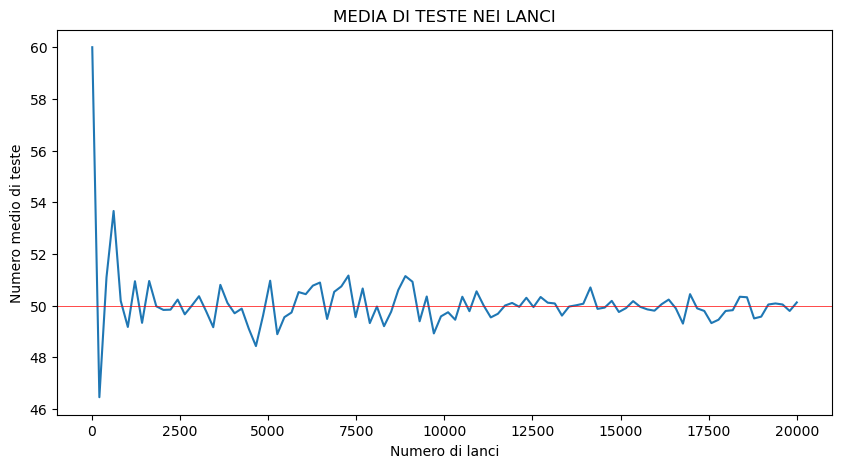

In [33]:
plt.figure(figsize=(10,5))
plt.plot(numero_lanci, risultati)
plt.axhline(y = 50, color='red', linewidth=0.5, label='Probabilità prevista')
plt.title('MEDIA DI TESTE NEI LANCI')
plt.xlabel('Numero di lanci')
plt.ylabel('Numero medio di teste')

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [17]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
df['Age'].isna().sum()

np.int64(177)

In [19]:
#print(df.count())
#df.index
#df.iloc[:].max()
#df['PassengerId'].max()
df.shape

# for colonna in df:
#     print(df[colonna].isnull().sum())

moda_embarked = df['Embarked'].mode()
#df[df['Embarked'].isnull() == True]['Embarked'] = moda_embarked #assegna su copia
#df.loc[df['Embarked'].isna(), 'Embarked'] = moda_embarked non funziona?
df['Embarked'] = df['Embarked'].fillna(moda_embarked)[0]
df.count()
df.duplicated().sum()

eta_media = df['Age'].mean()
#df['Age'].fillna(eta_media, inplace=True)
df.fillna({'Age': eta_media}, inplace=True)
df.isna().sum()
#da rivedere
# df.isnull()[df['Pclass'] == 1]['Age'].sum()
# df.isnull()[df['Pclass'] == 2]['Age'].sum()
# df.isnull()[df['Pclass'] == 3]['Age'].sum()

# #df[df['Pclass'] == 1, df.isnull()['Age'] == True]

# df_eta = df[df.isnull()['Age']]
# df_eta.groupby('Pclass')['Pclass'].sum()

# df.groupby('Pclass')[df['Age'].isnull()].sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

<Axes: xlabel='Pclass', ylabel='Age'>

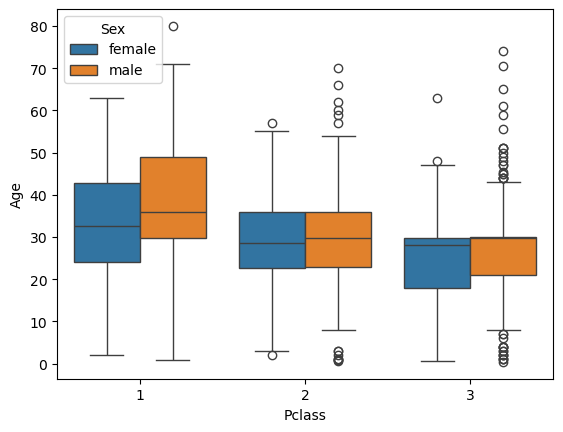

In [21]:
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex')

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.shape

(150, 5)

In [23]:
#1
#Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
df.value_counts('species')

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [25]:
#2
#Calcola la lunghezza e la larghezza media dei petali per specie
df.groupby('species')[['petal_length', 'petal_width']].mean()

,petal_length,petal_width
species,,
setosa,1.462,0.246
versicolor,4.260,1.326
virginica,5.552,2.026


<Axes: xlabel='petal_length', ylabel='petal_width'>

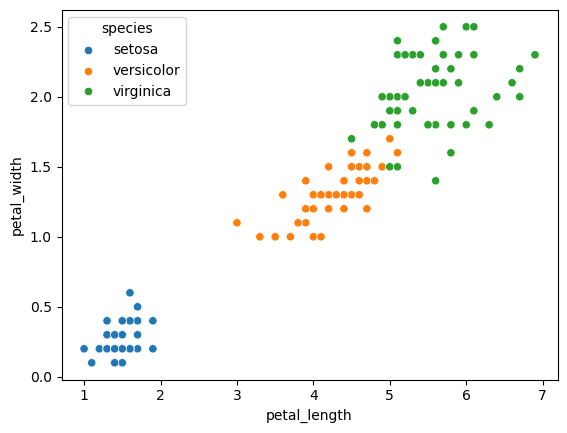

In [31]:
#3
#Visualizza le dimensioni dei petali per specie (scatterplot)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')

Text(0.5, 1.0, "QUANTO INCIDONO LE DIMENSIONI SULL'AREA")

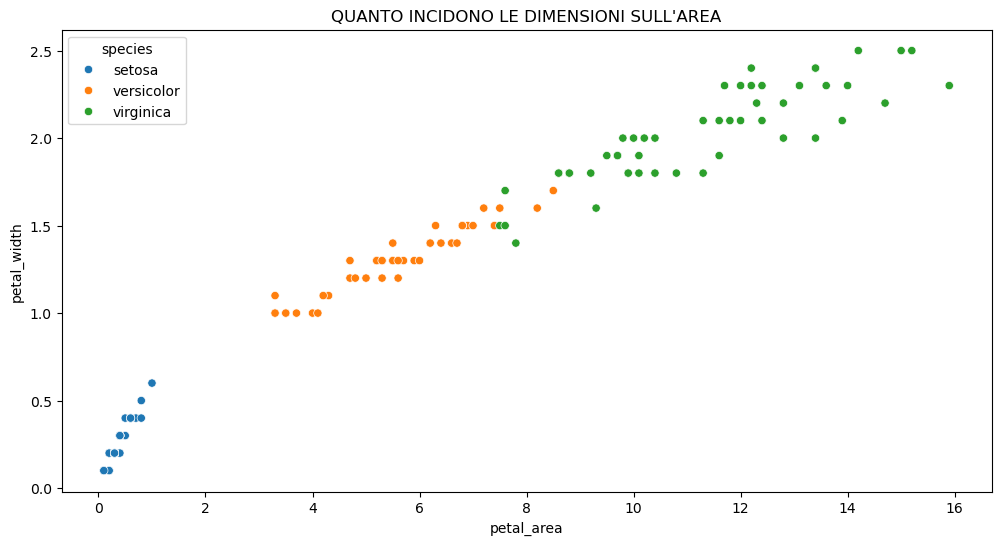

In [53]:
#4
#Crea una nuova colonna per l'area del petalo e analizzala
#suppongo che l'area sia petal_length * petal_width
df['petal_area'] = round(df['petal_length']*df['petal_width'], 1)
df.head()

#implementa con i suplot i grafici troppo piccoli
area_media = df.groupby('species')['petal_area'].mean()
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='petal_area', y='petal_width', hue='species')
plt.title("QUANTO INCIDONO LE DIMENSIONI SULL'AREA")

<Axes: xlabel='petal_width'>

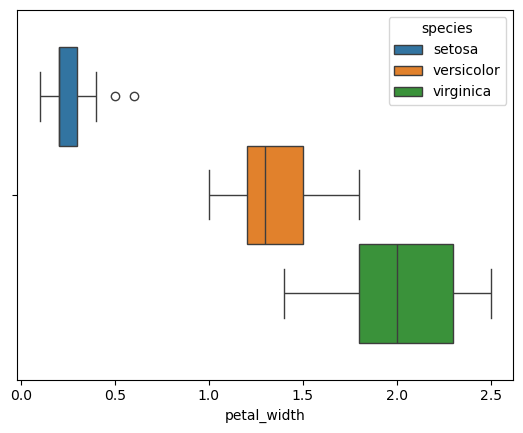

In [54]:
#5
#Grafico della distribuzione dell'area del petalo per specie (boxplot)
sns.boxplot(data=df, x='petal_width', hue='species')